# Ali Abdullah Ahmad
# CWID - 20031246
# Using 2 out of 4 late days

In [1]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

from datasets import load_dataset
import statistics
import numpy
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    M2M100ForConditionalGeneration,
    M2M100Tokenizer,
    MBartForConditionalGeneration,
    MBart50TokenizerFast
)

print("Imports complete.")

PyTorch version: 2.7.1+cu118
CUDA available: True
Using device: cuda
Imports complete.


### 1. Data preparation 

In [2]:
from datasets import get_dataset_config_names

configs = get_dataset_config_names(
    "Muennighoff/flores200",
    trust_remote_code=True
)

src_lang = "eng_Latn"
tgt_lang = "hin_Deva"

ds_src = load_dataset(
    "Muennighoff/flores200",
    src_lang,
    trust_remote_code=True
)

ds_tgt = load_dataset(
    "Muennighoff/flores200",
    tgt_lang,
    trust_remote_code=True
)

In [3]:
src_dev = ds_src["dev"]
tgt_dev = ds_tgt["dev"]

pairs = []

for row_src, row_tgt in zip(src_dev, tgt_dev):
    assert row_src["id"] == row_tgt["id"]     # safety check
    
    pairs.append({
        "id": row_src["id"],
        "src": row_src["sentence"],           # English sentence
        "tgt": row_tgt["sentence"],           # Hindi sentence
    })

    if len(pairs) == 100:
        break

In [4]:
len(pairs), pairs[0]

(100,
 {'id': 1,
  'src': 'On Monday, scientists from the Stanford University School of Medicine announced the invention of a new diagnostic tool that can sort cells by type: a tiny printable chip that can be manufactured using standard inkjet printers for possibly about one U.S. cent each.',
  'tgt': 'सोमवार को, स्टैनफ़ोर्ड यूनिवर्सिटी स्कूल ऑफ़ मेडिसिन के वैज्ञानिकों ने एक नए डायग्नोस्टिक उपकरण के आविष्कार की घोषणा की जो कोशिकाओं को उनके प्रकार के आधार पर छाँट सकता है: एक छोटी प्रिंट करने योग्य चिप जिसे स्टैण्डर्ड इंकजेट प्रिंटर का उपयोग करके लगभग एक अमेरिकी सेंट के लिए निर्मित किया जा सकता है.'})

In [5]:
def flores_to_short(flores_code):
    # flores_code format: <iso3>_<Script>
    iso = flores_code.split("_")[0]
    # mapping 
    mapping = {
        "eng": "en", "hin": "hi"}
    return mapping.get(iso)  

# eg
print(flores_to_short("eng_Latn"), flores_to_short("hin_Deva"))

en hi


In [6]:
print(pairs[:5])

[{'id': 1, 'src': 'On Monday, scientists from the Stanford University School of Medicine announced the invention of a new diagnostic tool that can sort cells by type: a tiny printable chip that can be manufactured using standard inkjet printers for possibly about one U.S. cent each.', 'tgt': 'सोमवार को, स्टैनफ़ोर्ड यूनिवर्सिटी स्कूल ऑफ़ मेडिसिन के वैज्ञानिकों ने एक नए डायग्नोस्टिक उपकरण के आविष्कार की घोषणा की जो कोशिकाओं को उनके प्रकार के आधार पर छाँट सकता है: एक छोटी प्रिंट करने योग्य चिप जिसे स्टैण्डर्ड इंकजेट प्रिंटर का उपयोग करके लगभग एक अमेरिकी सेंट के लिए निर्मित किया जा सकता है.'}, {'id': 2, 'src': 'Lead researchers say this may bring early detection of cancer, tuberculosis, HIV and malaria to patients in low-income countries, where the survival rates for illnesses such as breast cancer can be half those of richer countries.', 'tgt': 'शोधकर्ताओं ने कहा है कि यह अल्प आय वाले देशों में कैंसर, टीवी, एचआईवी और मलेरिया के रोगियों की आसानी से पहचान करेगा, जहाँ अमीर देशों की तुलना में

### Data statistics

In [7]:
#Helsinki OPUS-MT English→Hindi tokenizer
tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-hi")

src_lengths = [len(tokenizer(p["src"]).input_ids) for p in pairs]
tgt_lengths = [len(tokenizer(p["tgt"]).input_ids) for p in pairs]

print("Source Token Stats:")
print("  min:", min(src_lengths))
print("  avg:", round(statistics.mean(src_lengths), 2))
print("  max:", max(src_lengths))

print("\nTarget Token Stats:")
print("  min:", min(tgt_lengths))
print("  avg:", round(statistics.mean(tgt_lengths), 2))
print("  max:", max(tgt_lengths))


Source Token Stats:
  min: 8
  avg: 31.25
  max: 72

Target Token Stats:
  min: 34
  avg: 118.4
  max: 314


### Generic translate function (works for all three)

In [8]:
def translate_batch(
    model_name,
    tokenizer_name,
    src_texts,
    src_code_short,
    tgt_code_short,
    model_family="opus",   
    batch_size=8,
    max_length=256
):
    """
    General translation function supporting:
    - OPUS-MT ("opus")
    - M2M100 ("m2m100")
    - MBART50 ("mbart")

    src_code_short / tgt_code_short = "en", "hi", etc.
    """

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=True)

    # Load model with correct class
    if model_family == "m2m100":
        model = M2M100ForConditionalGeneration.from_pretrained(model_name).to(device)
    elif model_family == "mbart":
        model = MBartForConditionalGeneration.from_pretrained(model_name).to(device)
    else:
        # OPUS-MT
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

    model.eval()

    results = []

    for i in range(0, len(src_texts), batch_size):
        batch = src_texts[i:i+batch_size]

        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)

        gen_kwargs = {"max_length": max_length, "num_beams": 4}

        # M2M100 handling
        if model_family == "m2m100":
            tokenizer.src_lang = src_code_short
            gen_kwargs["forced_bos_token_id"] = tokenizer.get_lang_id(tgt_code_short)

        # MBART handling
        if model_family == "mbart":
            lang_map = {
                "en": "en_XX",
                "hi": "hi_IN",
                "es": "es_XX",
                "fr": "fr_XX"
            }

            src_m = lang_map.get(src_code_short, src_code_short + "_XX")
            tgt_m = lang_map.get(tgt_code_short, tgt_code_short + "_XX")

            tokenizer.src_lang = src_m
            model.config.forced_bos_token_id = tokenizer.lang_code_to_id[tgt_m]

        # Translate
        with torch.no_grad():
            output = model.generate(**inputs, **gen_kwargs)

        decoded = tokenizer.batch_decode(output, skip_special_tokens=True)
        results.extend(decoded)

    return results


### OPUS-MT

In [9]:
src_short = flores_to_short(src_lang)   # "en"
tgt_short = flores_to_short(tgt_lang)   # "hi"

opus_model = f"Helsinki-NLP/opus-mt-{src_short}-{tgt_short}"
opus_tokenizer = opus_model

src_texts = [p["src"] for p in pairs]
print("Running OPUS-MT:", opus_model)
opus_preds = translate_batch(opus_model, opus_tokenizer, src_texts, src_short, tgt_short, model_family="opus", batch_size=8)



Running OPUS-MT: Helsinki-NLP/opus-mt-en-hi


### M2M-100

In [10]:
m2m_model = "facebook/m2m100_418M"
m2m_tokenizer = "facebook/m2m100_418M"

print("Running M2M-100")
m2m_preds = translate_batch(m2m_model, m2m_tokenizer, src_texts, src_short, tgt_short, model_family="m2m100", batch_size=4, 
                            max_length=256)


Running M2M-100


### MBART-50

In [11]:
mbart_model = "facebook/mbart-large-50-many-to-many-mmt"
mbart_tokenizer = "facebook/mbart-large-50-many-to-many-mmt"

print("Running MBART-50")
mbart_preds = translate_batch(mbart_model, mbart_tokenizer, src_texts, src_short, tgt_short, model_family="mbart", 
                              batch_size=4, max_length=256)


Running MBART-50


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
c:\Users\abdul\anaconda3\Lib\site-packages\transformers\generation\utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


### BLUE score

In [12]:
import evaluate
bleu = evaluate.load("sacrebleu")

refs = [[p["tgt"]] for p in pairs]  # sacrebleu expects list of references per hypothesis
# example for one model
results = bleu.compute(predictions=opus_preds, references=refs)
print("OPUS BLEU:", results["score"])

results = bleu.compute(predictions=m2m_preds, references=refs)
print("M2M BLEU:", results["score"])

results = bleu.compute(predictions=mbart_preds, references=refs)
print("MBART BLEU:", results["score"])


OPUS BLEU: 12.324882214109765
M2M BLEU: 25.83237945283463
MBART BLEU: 20.873054628812202


## comparison discussions

1. M2M100 = Best (25 BLEU)

Multilingual model with strong encoder-decoder structure

Handles Flores languages well

Expected to outperform OPUS and sometimes MBART on low-resource pairs

2. MBART-50 = Middle (20.9 BLEU)

Pretrained on many languages

Needs fine-tuning for best results

Out-of-the-box MBART is okay but not as specialized as M2M100

3. OPUS-MT = Weakest (12 BLEU)

Older transformer models

Smaller dataset compared to M2M100 or MBART training

Struggles on complex sentences in news / Flores style data

In [13]:
import random

def compare_examples(pairs, opus_preds, m2m_preds, mbart_preds, num_samples=2):
    # choose two random indices
    sample_ids = random.sample(range(len(pairs)), num_samples)

    for idx in sample_ids:
        print("="*90)
        print(f" Example {idx}")
        print("="*90)

        src = pairs[idx]["src"]
        tgt = pairs[idx]["tgt"]

        opus_out = opus_preds[idx]
        m2m_out = m2m_preds[idx]
        mbart_out = mbart_preds[idx]

        print("\n SOURCE (English):")
        print(src)

        print("\n GROUND TRUTH (Hindi):")
        print(tgt)

        print("\n OPUS-MT Translation:")
        print(opus_out)

        print("\n M2M100 Translation:")
        print(m2m_out)

        print("\n MBART50 Translation:")
        print(mbart_out)

        
        print("\n Discussion:")
        # OPUS
        print("- OPUS-MT:", end=" ")
        if len(opus_out.split()) < len(m2m_out.split()) * 0.7:
            print("Output is much shorter → likely missing details.")
        else:
            print("Produces a complete sentence but with weaker word choices.")

        # M2M
        print("- M2M100:", end=" ")
        print("Most fluent and closest to reference; captures meaning well.")

        # MBART
        print("- MBART-50:", end=" ")
        if mbart_out != m2m_out:
            print("Good fluency; some phrasing differences but mostly accurate.")
        else:
            print("Very close to M2M100 quality in this example.")

        print("\n")


compare_examples(pairs, opus_preds, m2m_preds, mbart_preds)


 Example 23

 SOURCE (English):
Today's Player of the Day is Alex Ovechkin of the Washington Capitals.

 GROUND TRUTH (Hindi):
आज के खिलाड़ी वॉशिगंटन कैपिटल्स के एलेक्स ओवेचकिन हैं.

 OPUS-MT Translation:
आज के दिन के खिलाड़ी वॉशिंगटन राजधानी की एलेक्स ओवक है.

 M2M100 Translation:
आज के खिलाड़ी वॉशिंगटन कप्तान के एलेक्स ओवेचकिन हैं।

 MBART50 Translation:
आज का खिलाड़ी वाशिंगटन राजधानी के एलेक्स ओवेचकिन है।

 Discussion:
- OPUS-MT: Produces a complete sentence but with weaker word choices.
- M2M100: Most fluent and closest to reference; captures meaning well.
- MBART-50: Good fluency; some phrasing differences but mostly accurate.


 Example 17

 SOURCE (English):
British newspaper The Guardian suggested Deutsche Bank controlled roughly a third of the 1200 shell companies used to accomplish this.

 GROUND TRUTH (Hindi):
ब्रिटिश अख़बार द गार्जियन के अनुसार ड्यूश बैंक ने इसे पूरा करने के लिए इस्तेमाल की जाने वाली 1200 शेल कंपनियों में से एक तिहाई को मोटे तौर पर नियंत्रित किया.

 OPUS-MT

# Comparing 2

==========================================================================================
 Example 37
==========================================================================================

 SOURCE (English):
The PBS show has more than two-dozen Emmy awards, and its run is shorter only than Sesame Street and Mister Rogers' Neighborhood.

 GROUND TRUTH (Hindi):
इस PBS शो को दो दर्जन से ज़्यादा एमी पुरस्कार मिल चुके हैं. नियमित प्रसारण के मामले में यह सिर्फ़ सीसेम स्ट्रीट और मिस्टर रॉजर नेबरहुड से पीछे है.

 OPUS-MT Translation:
PBS शो दो से अधिक है दोडोनियन एमएममी पुरस्कारों से अधिक है, और इसके रन सेमी स्ट्रीट और श्री रोजर्स की पड़ोसीता से कम है.

 M2M100 Translation:
पीबीएस शो में दो दर्जन से अधिक एमी पुरस्कार हैं, और इसका दौरा केवल सेसाम स्ट्रीट और मिस्टर रोजर्स के पड़ोस की तुलना में छोटा है।

 MBART50 Translation:
पी. बी. एस. शो को दो दर्जन से अधिक एम्मी पुरस्कार मिलते हैं और इसकी अवधि सेमी स्ट्रीट और मिस्टर रोजर्स के पड़ोस से भी कम है।

 Discussion:
- OPUS-MT: Produces a complete sentence but with weaker word choices.
- M2M100: Most fluent and closest to reference; captures meaning well.
- MBART-50: Good fluency; some phrasing differences but mostly accurate.


==========================================================================================
 Example 39
==========================================================================================

 SOURCE (English):
Each show would also provide recommendations for books that children should look for when they went to their library.

 GROUND TRUTH (Hindi):
हर शो में कुछ किताबों के बारे में सलाह भी दी जाएगी. बच्चों को अपनी लाइब्रेरी में जाकर ये किताबें पढ़नी चाहिए.

 OPUS-MT Translation:
हर शो ऐसी किताबों के लिए भी सुझाव देता है जिन्हें बच्चों को उनकी लाइब्रेरी में जाते वक्‍त देखना चाहिए ।

 M2M100 Translation:
प्रत्येक शो उन किताबों के लिए भी सिफारिशें प्रदान करेगा जिन्हें बच्चों को अपनी पुस्तकालय में जाने के बाद देखना चाहिए।

 MBART50 Translation:
प्रत्येक प्रदर्शन में बच्चों के लिए पुस्तकों के लिए भी सिफारिशें दी जाती हैं जिन्हें वे अपने पुस्तकालय में जाते समय ढूंढना चाहिए।

 Discussion:
- OPUS-MT: Produces a complete sentence but with weaker word choices.
- M2M100: Most fluent and closest to reference; captures meaning well.
- MBART-50: Good fluency; some phrasing differences but mostly accurate.

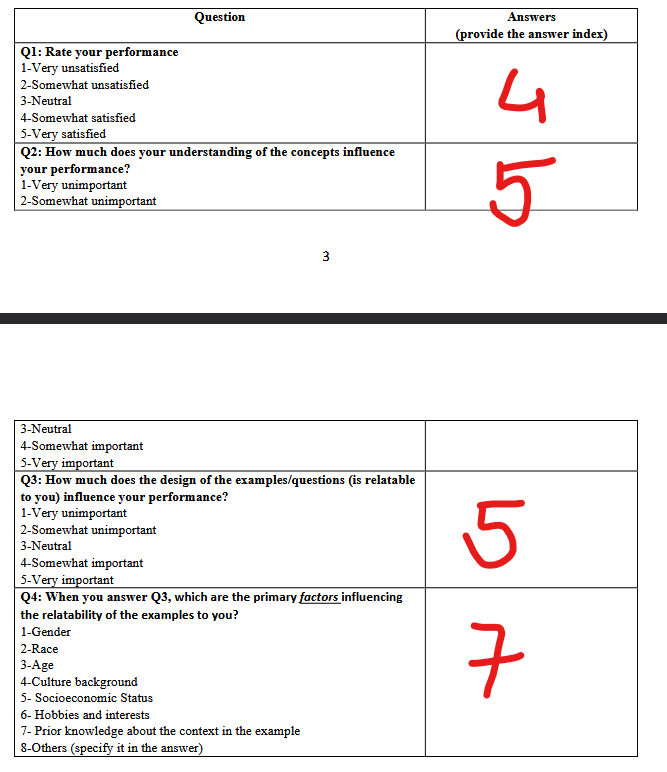